In [2]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

# Display first few rows
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


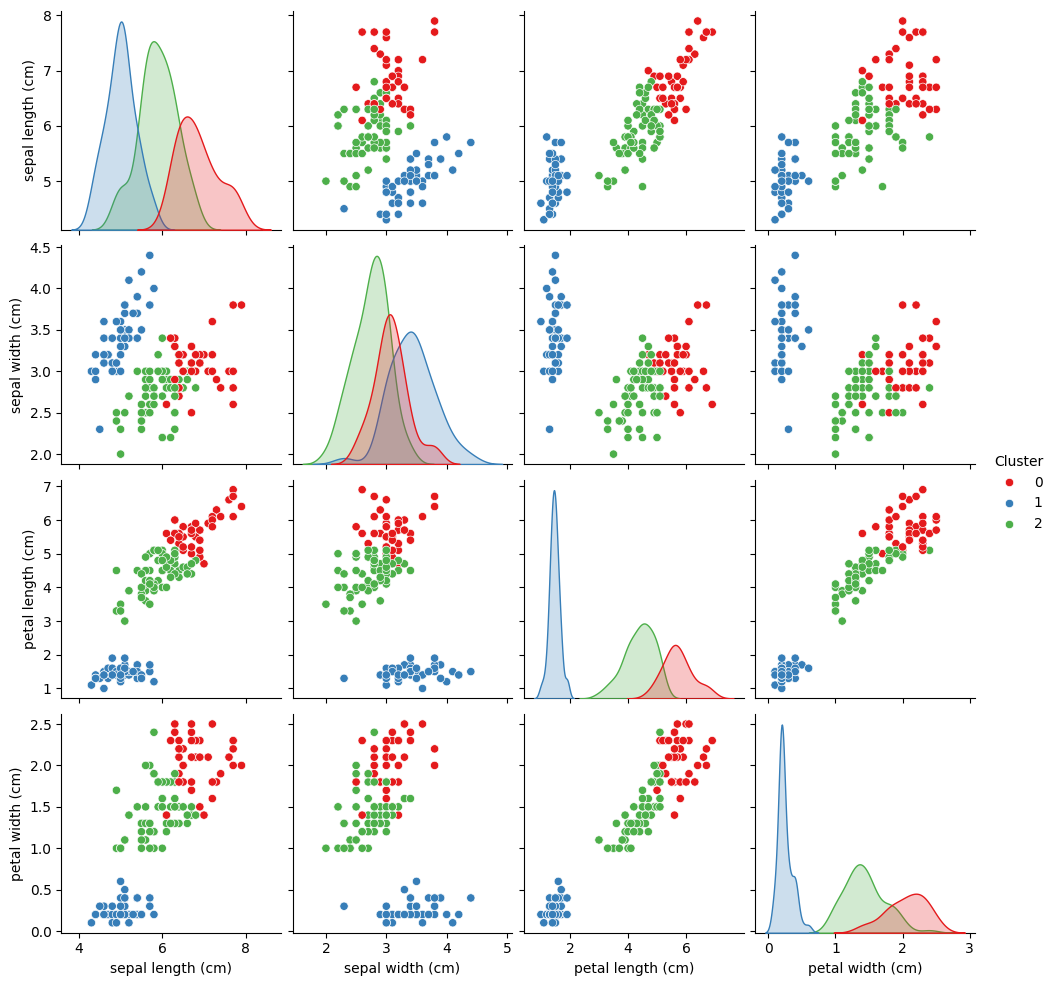

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Choose number of clusters (3, since Iris has 3 species)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Cluster labels
labels = kmeans.labels_

# Add labels to dataset for visualization
X['Cluster'] = labels

# Visualization using pairplot
sns.pairplot(X, hue='Cluster', palette='Set1')
plt.show()


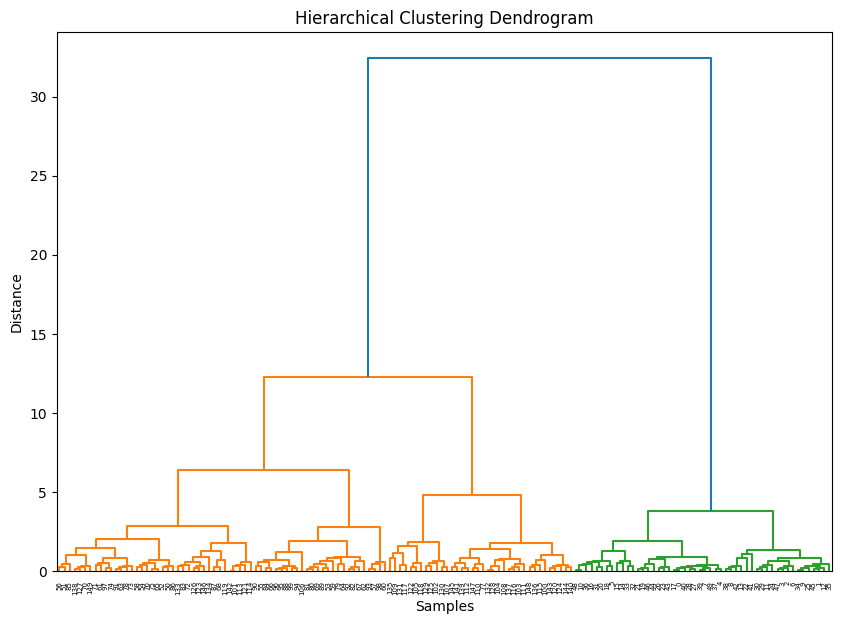

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Perform hierarchical clustering using 'ward' linkage
linked = linkage(X.drop('Cluster', axis=1), method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Optional: Assign cluster labels from dendrogram
hc_labels = fcluster(linked, 3, criterion='maxclust')
X['HC_Cluster'] = hc_labels

# Pairplot to visualize clusters
sns.pairplot(X, hue='HC_Cluster', palette='Set2')
plt.show()
